# Computation of $S_{21}$ (Theory)

## Functions

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.collections import LineCollection
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
from matplotlib.ticker import AutoMinorLocator
import scipy.signal as signal

In [8]:
def S21(Delta_omega: float, kappa_0: float, kappa_ex: float):
    """
    Compute the response of vna (S21)

    Args:
        Delta_omega (float): Frequency
        kappa_0 (float): Internal losses
        kappa_ex (float): Coupling losses

    Returns:
        float: Value of S21
    """

    return (kappa_0 - kappa_ex - 2 * 1j * Delta_omega) / (kappa_0 + kappa_ex - 2 * 1j * Delta_omega)

In [28]:
def plot_S21(f_0: float, Q_0: float, Q_ex: float, nb_points: int):
    """
    Plot the response of the VNA (S21).

    Args:
        f_0 (float): Central frequency
        Q_0 (float): Quality factor of the cavity
        Q_ex (float): Quality factor of the coupling
        nb_points (int): Number of points

    Returns:
        None
    """

    omega_0 = 2 * np.pi * f_0
    kappa_0 = omega_0 / Q_0
    kappa_ex = omega_0 / Q_ex
    kappa_tot = kappa_0 + kappa_ex
    beta = kappa_ex / kappa_0

    bandwidth = 10 * kappa_tot / (2 * np.pi)
    freqs = np.linspace(f_0 - (bandwidth / 2), f_0 + (bandwidth / 2), nb_points)
    freqs_GHz = freqs * 1e-9
    omegas = 2 * np.pi * freqs

    delta_omegas = omega_0 - omegas
    delta_freqs = f_0 - freqs
    delta_freqs_MHz = delta_freqs * 1e-6

    S21 = ((kappa_0 - kappa_ex) / 2 - 1j * delta_omegas) / ((kappa_0 + kappa_ex) / 2 - 1j * delta_omegas)
    S21_dB = 20 * np.log10(np.abs(S21))
    S21_phase = np.angle(S21)
    S21_phase = np.unwrap(np.angle(S21)) 
    S21_phase = np.rad2deg(S21_phase)
    S21_I = S21.real
    S21_Q = S21.imag
    
    min_dB = 20 * np.log10(np.abs((kappa_ex - kappa_0) / (kappa_ex + kappa_0)))
    
    peaks, _ = signal.find_peaks(-S21_dB)

    results_half = signal.peak_widths(-S21_dB, peaks, rel_height=0.5)

    widths = results_half[0]

    fig = plt.figure(figsize=(12, 6))

    gs = gridspec.GridSpec(2, 2, width_ratios = [1.6, 1])

    ax_dB = fig.add_subplot(gs[0,0])
    ax_phase = fig.add_subplot(gs[1, 0], sharex=ax_dB)
    ax_IQ = fig.add_subplot(gs[:, 1])

    ax_dB.plot(delta_freqs_MHz, S21_dB, linewidth=1.6)

    ax_dB.axvline(0, linewidth=0.8, linestyle='--', alpha=0.7)
    ax_dB.scatter(0, min_dB, s=25)

    ax_dB.set_ylabel("$|S_{21}|$ (dB)", fontsize=10)
    ax_dB.set_ylim(bottom=1.1*S21_dB.min())
    ax_dB.set_title(f"FWHM: {widths[0]:.2f} MHz")
    ax_dB.grid()

    ax_phase.plot(delta_freqs_MHz, S21_phase, linewidth=1.6)
    ax_phase.axvline(0, linewidth=0.8, linestyle="--", alpha=0.7)

    ax_phase.set_xlabel("Frequency (MHz)", fontsize=10)
    ax_phase.set_ylabel("$\\rm{arg}(S_{11})$ (deg)", fontsize=10)
    ax_phase.grid()

    #ax_phase.set_yticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi])
    #ax_phase.set_yticklabels(["$-\pi$", "$-\\frac{\pi}{2}$", "$0$", "$\\frac{\pi}{2}$", "$\pi$"])

    points = np.array([S21_I, S21_Q]).T.reshape(-1, 1, 2)
    segs = np.concatenate([points[:-1], points[1:]], axis=1)
    lc = LineCollection(segs, colors='tab:blue', linewidth=2.2, alpha=0.9)
    ax_IQ.add_collection(lc)

    pad = 0.05
    ax_IQ.set_xlim(S21_I.min() - pad, S21_I.max() + pad)
    ax_IQ.set_ylim(S21_Q.min() - pad, S21_Q.max() + pad)
    ax_IQ.set_aspect("equal")
    ax_IQ.set_xlabel("$I$", fontsize=10)
    ax_IQ.set_ylabel("$Q$", fontsize=10)
    ax_IQ.set_title("Plan IQ", fontsize=10, pad=8)
    ax_IQ.grid()
    
    regime = "Overcoupled regime" if beta > 1 else ("Critical coupling" if beta == 1 else "Undercoupled regime")

    fig.suptitle(
        f"Signal $S_{{21}}$ — Cylindric Microwave Cavity\n $f_0 = {f_0 * 1e-9:.2f}$ GHz | $Q_0 = {Q_0:,}$ | $\kappa_0 = {kappa_0*1e-6:.2f}$ MHz | $Q_e = {Q_ex:,}$ | $\kappa_e = {kappa_ex*1e-6:.2f} MHz$\n {regime}", fontsize=10, y=1, linespacing=1.6,
    )

    plt.show()

## Plots

### Undercoupled

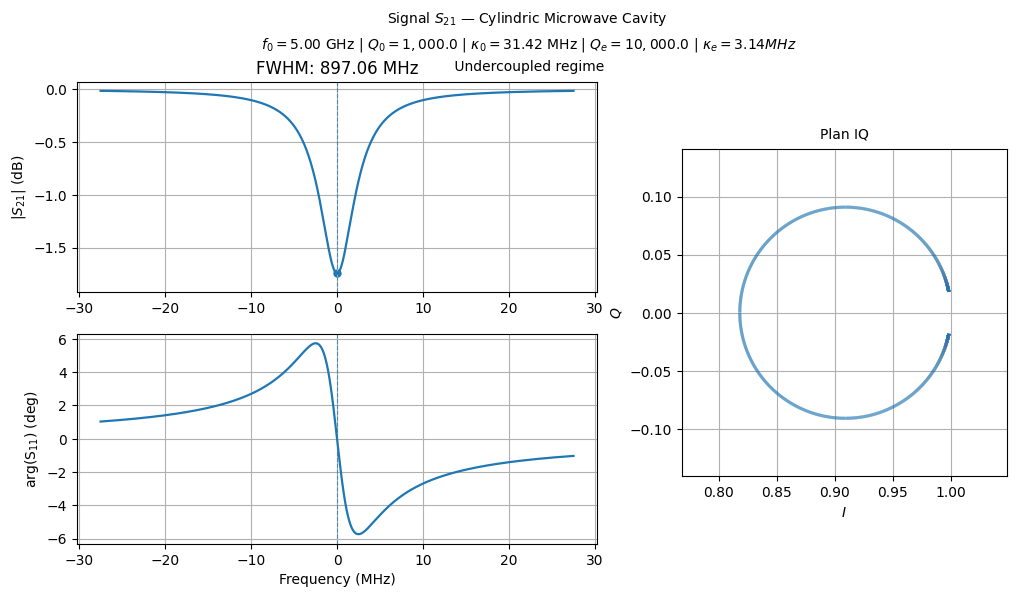

In [29]:
plot_S21(5e9, 1e3, 1e4, 10000)

### Critical regime

/tmp/ipykernel_83/2288625905.py:38: RuntimeWarning: divide by zero encountered in log10
  min_dB = 20 * np.log10(np.abs((kappa_ex - kappa_0) / (kappa_ex + kappa_0)))


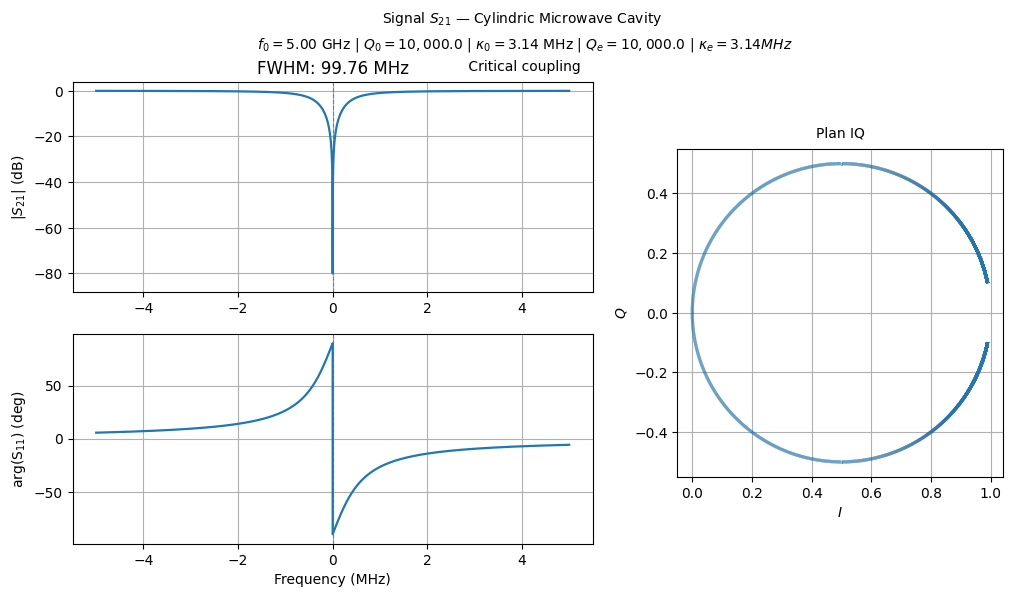

In [31]:
plot_S21(5e9, 1e4, 1e4, 100000)

### Overcoupled

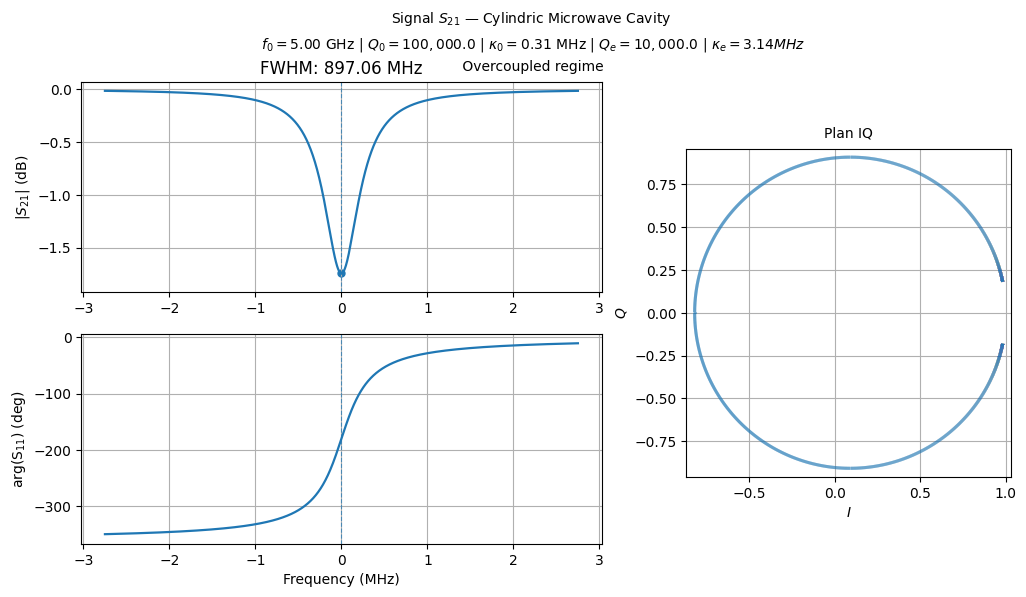

In [32]:
plot_S21(5e9, 1e5, 1e4, 10000)

Place the pin such as the cavity is always in the overcoupled regime allows to always have a sharp change in the phase. Thus, we can easily use the maximum of the gradient to localize the resonance (Don't forget to use np.unwrap before calculating the gradient). The ideal situation is to be always in the critical regime since it's the regime with the biggest extinction, but it remains difficult according to the authors.